# Credit Card Fraud Detection — Reproducible Preprocessing Notebook

## Objective
In this notebook, I am building a clear and reproducible preprocessing workflow for the MLG-ULB credit card fraud dataset.

My goal is not just to “clean” the data, but to prepare it properly for downstream modelling in a way that is transparent, leakage-safe, and easy for my teammates to follow. I want every preprocessing decision in this notebook to be documented with a reason, so that nothing appears arbitrary.

More specifically, I will use this notebook to:
- load the raw dataset safely,
- validate the structure of the data,
- inspect data quality issues such as missing values and duplicates,
- study the class imbalance and feature distributions,
- prepare train/test splits correctly,
- apply model-aware preprocessing where needed,
- and export reusable outputs for later modelling.

## Dataset Summary
The dataset used in this project is the MLG-ULB Credit Card Fraud Detection dataset.

It contains:
- 284,807 transactions,
- 492 fraud cases,
- a fraud rate of 0.172%.

The features include:
- `Time`
- `Amount`
- `V1` to `V28`, which are anonymised PCA-transformed numerical variables
- `Class`, where 0 represents a legitimate transaction and 1 represents a fraudulent transaction

## Why this notebook matters
This dataset is already largely numerical and structured, so the preprocessing stage here is more about making careful methodological decisions than doing heavy cleaning.

I want this notebook to act as a reliable preprocessing foundation for the whole group, so that later modelling results can be explained properly in the report and presentation.

## How I am running this notebook

I am running this notebook in a separate virtual environment and dedicated Jupyter kernel created specifically for this coursework. I chose to do that to keep the project isolated, reproducible, and free from dependency conflicts with my other modules and previous coursework.

### Recommended setup
This notebook is intended to run with:
- Python 3.10 or above
- Jupyter Notebook / JupyterLab / VS Code Notebook

### Required libraries
The main libraries used in this notebook are:
- pandas
- numpy
- matplotlib
- scipy
- scikit-learn
- imbalanced-learn

### Environment setup
I created a dedicated environment for this project and installed the required packages before running the notebook.

### Expected folder structure
For this notebook to run correctly, I place the dataset file here:

```text
./data/creditcard.csv

## Reproducibility note

I am using a fixed random seed throughout this notebook so that the workflow remains reproducible.

This is important because I want:
- the same train/test split to be generated each time,
- later experiments to stay comparable,
- my teammates to be able to reproduce the same outputs,
- and all preprocessing steps to remain traceable.

I use `SEED = 42` as a consistent convention in this project. The exact value itself is not special, but keeping it fixed across the notebook is important for reproducibility.

## Preprocessing approach used in this notebook

Before starting the code, I want to make my preprocessing approach clear.

Since the dataset is already numerical and anonymised, I do not expect heavy cleaning in the traditional sense, such as categorical encoding or text processing. Instead, I will focus on the parts of preprocessing that matter most for this task:
- validating the data structure,
- checking for missing values and duplicates,
- understanding the severe class imbalance,
- inspecting the raw variables that may need special treatment,
- avoiding data leakage,
- and preparing outputs that are suitable for different model families.

I also want this notebook to be easy to understand from start to finish, so I will include comments, notes, and reasoning wherever necessary.

In [2]:
import sys
import json
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler

In [45]:
# ------------------------------------------------------------------
# Reproducibility configuration
# ------------------------------------------------------------------
# In machine learning experiments, randomness can affect several steps:
# - train/test data splitting
# - cross-validation shuffling
# - sampling procedures
# - model initialization in some algorithms
#
# To ensure that our preprocessing pipeline produces the same results
# each time it is executed (both for teammates and future reruns),
# we fix a random seed across the notebook.
#
# The value 42 is a commonly used convention in ML examples.
# The exact value itself is not important, but keeping it fixed ensures
# that the workflow remains reproducible and traceable.
# ------------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
random.seed(SEED)


# ------------------------------------------------------------------
# Notebook display configuration
# These settings make tables easier to inspect during analysis.
# ------------------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


# ------------------------------------------------------------------
# Project paths
# DATA_PATH: location of the raw dataset
# OUTPUT_DIR: location where preprocessed outputs will be saved
# ------------------------------------------------------------------

DATA_PATH = Path("../data/creditcard.csv")

OUTPUT_DIR = Path("../outputs/preprocessed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [46]:
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Random seed used:", SEED)

print("\nDataset path:", DATA_PATH)
print("Output directory:", OUTPUT_DIR.resolve())

print("\nLibrary versions")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python version: 3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:08) [Clang 20.1.8 ]
Platform: macOS-14.4-arm64-arm-64bit-Mach-O
Random seed used: 42

Dataset path: ../data/creditcard.csv
Output directory: /Users/harsh/DM_CW/outputs/preprocessed

Library versions
NumPy: 2.4.3
Pandas: 3.0.1


## Data loading and first inspection

At this stage, I want to load the raw dataset exactly as provided and inspect its basic structure before making any preprocessing decisions.

I am doing this first because I do not want to assume that the dataset is perfectly formatted, even if it is a widely used benchmark dataset. In a reproducible workflow, it is important to verify the file structure, dimensions, column names, and general appearance of the data before moving into cleaning or transformation steps.

This also helps me document the starting point of the analysis clearly, so that any later preprocessing decisions can be linked back to what I actually observed in the raw data.

In [12]:
def section(title: str):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

In [13]:
section("Load raw dataset")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Please place 'creditcard.csv' inside the data folder or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Load raw dataset
Dataset loaded successfully.
Shape: (284807, 31)


## Schema validation

Now that the raw dataset has been loaded successfully, I want to verify that its structure matches what is expected from the MLG-ULB credit card fraud dataset.

I am doing this step before any preprocessing because a dataset can load successfully and still contain structural problems, such as missing columns, renamed columns, unexpected ordering, or target-related issues. If those problems are not detected early, they can silently affect later steps in the workflow.

At this stage, I want to confirm:
- that all expected columns are present,
- that the target column is available,
- that the PCA-transformed variables `V1` to `V28` are included,
- and that the dataset looks consistent with the benchmark version I intend to use.

This validation step helps me document that the preprocessing workflow started from the correct raw dataset rather than assuming it.

In [16]:
def assert_required_columns(df: pd.DataFrame, required_columns: list[str]):
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    print("All required columns are present.")

In [18]:
section("Initial schema validation")

expected_columns = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]

assert_required_columns(df, expected_columns)

print("\nNumber of columns found:", len(df.columns))
print("Number of expected columns:", len(expected_columns))
print("Column names in dataset:")
print(df.columns.tolist())
print("Data types:")
print(df.dtypes)


Initial schema validation
All required columns are present.

Number of columns found: 31
Number of expected columns: 31
Column names in dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


## Why this schema check matters

I included this schema check to make the preprocessing workflow more robust and transparent.

Even when working with a well-known public dataset, I do not want to rely on assumptions such as:
- the file always having the correct columns,
- the target column always being present,
- or the file always matching the original benchmark structure.

By validating the schema explicitly, I can justify that:
- the notebook is being run on the intended dataset,
- the target variable is available for supervised evaluation,
- and the preprocessing logic that follows is based on the correct feature set.

This is a small step technically, but it improves the reliability of the whole pipeline.

## Basic data audit

Before performing any preprocessing steps, I want to conduct a basic audit of the dataset.

The goal of this step is to understand the overall quality and structure of the data before applying any transformations or cleaning operations.

Specifically, I want to examine:
- whether there are any missing values in the dataset,
- whether some columns contain unexpected values,
- whether duplicate rows exist,
- and whether the dataset appears structurally consistent.

Even though this dataset is widely used in research and benchmarking, I do not want to assume that it is perfectly clean. Performing this audit allows me to justify later preprocessing decisions based on actual observations rather than assumptions.

In [19]:
def basic_data_audit(df: pd.DataFrame):

    audit = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isnull().sum(),
        "missing_percentage": (df.isnull().sum() / len(df)) * 100,
        "unique_values": df.nunique()
    })

    return audit

In [20]:
section("Basic dataset audit")

audit_table = basic_data_audit(df)

audit_table


Basic dataset audit


,dtype,missing_count,missing_percentage,unique_values
Time,float64,0,0.000000,124592
V1,float64,0,0.000000,275663
V2,float64,0,0.000000,275663
V3,float64,0,0.000000,275663
V4,float64,0,0.000000,275663
V5,float64,0,0.000000,275663
V6,float64,0,0.000000,275663
V7,float64,0,0.000000,275663
V8,float64,0,0.000000,275663
V9,float64,0,0.000000,275663


## Observations from the data audit

From the audit results above, I can evaluate whether the dataset contains missing values or structural issues.

For the credit card fraud dataset, I expect the following:
- all features should be numerical,
- missing values should be minimal or absent,
- the dataset should contain the full set of anonymised PCA features,
- and the target variable `Class` should only contain binary values (0 and 1).

If the audit confirms these expectations, it suggests that the dataset is structurally clean and that preprocessing will focus more on modelling considerations rather than heavy data cleaning.

## Duplicate row analysis

Before deciding whether to remove duplicates, I want to first check whether the dataset actually contains any duplicate rows.

In fraud detection datasets, duplicates require careful interpretation. A duplicate row could represent:
- a repeated transaction that legitimately occurred more than once, or
- a duplicated record created during data processing.

Because of this ambiguity, I do not want to automatically remove duplicates without first understanding their extent.

In this step, I will:
- calculate how many duplicate rows exist,
- examine their proportion relative to the dataset size,
- and then decide whether removal is justified.

In [21]:
section("Duplicate row detection")

duplicate_count = df.duplicated().sum()

duplicate_percentage = (duplicate_count / len(df)) * 100

print("Total rows:", len(df))
print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 6), "%")


Duplicate row detection
Total rows: 284807
Duplicate rows: 1081
Duplicate percentage: 0.379555 %


## Duplicate handling decision

The dataset contains 1081 duplicate rows.

Since these rows are exact duplicates across all variables, they do not introduce any additional information for the learning algorithms. Instead, they may artificially reinforce identical observations during model training.

For this reason, I decided to remove exact duplicate rows from the dataset before continuing with the preprocessing workflow.

This step ensures that the dataset reflects unique transactions and prevents potential bias caused by repeated identical samples.

Before removing duplicates, I will record the dataset size so that the change in dataset size can be documented clearly.

In [24]:
section("Removing duplicate rows")

rows_before = len(df)

df = df.drop_duplicates().copy()

rows_after = len(df)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Duplicates removed:", rows_before - rows_after)


Removing duplicate rows
Rows before duplicate removal: 284807
Rows after duplicate removal: 283726
Duplicates removed: 1081


## Observation after duplicate removal

After removing exact duplicates, the dataset now contains 283,726 unique transactions.

This step slightly reduces the dataset size but ensures that the training data does not contain repeated identical observations.

The next stage of the preprocessing workflow focuses on understanding the class imbalance in the dataset, which is one of the most important challenges in credit card fraud detection.

## Class distribution analysis

One of the most important characteristics of the credit card fraud dataset is the extreme class imbalance between legitimate and fraudulent transactions.

Understanding this imbalance is essential before building any predictive model, because it directly affects:
- model training behaviour,
- evaluation metrics,
- and the choice of modelling techniques.

If the dataset contains a very small proportion of fraud cases, a model could achieve very high accuracy simply by predicting all transactions as legitimate. However, such a model would be useless in practice because it would fail to detect fraudulent activity.

For this reason, I want to carefully examine the distribution of the target variable `Class` before proceeding further in the workflow.

In [25]:
section("Class distribution")
class_counts = df["Class"].value_counts().sort_index()
class_counts


Class distribution


Class
0    283253
1       473
Name: count, dtype: int64

In [26]:
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100
class_percentages

Class
0   99.833290
1    0.166710
Name: proportion, dtype: float64

In [27]:
class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages
})
class_summary.index = ["Legitimate (0)", "Fraud (1)"]
class_summary

,count,percentage
Legitimate (0),283253,99.833290
Fraud (1),473,0.166710


## Observation: extreme class imbalance

The dataset is extremely imbalanced. Legitimate transactions represent the vast majority of observations, while fraudulent transactions form only a very small fraction of the dataset.

This imbalance has several important implications:

- Standard accuracy metrics can be misleading.
- A naive model that predicts every transaction as legitimate could still achieve very high accuracy.
- Detecting fraud therefore requires models that can identify rare patterns within a large number of normal transactions.

Because of this imbalance, later modelling stages will need to consider:
- stratified train-test splitting,
- appropriate evaluation metrics,
- and potentially sampling techniques.

For evaluation, metrics such as **precision, recall, F1-score, PR-AUC, and ROC-AUC** are more informative than accuracy alone.


Visualizing class imbalance


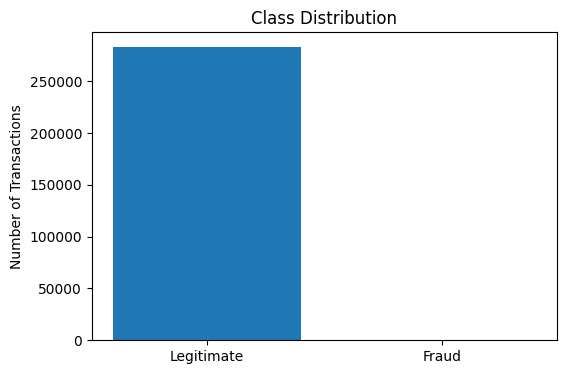

In [28]:
section("Visualizing class imbalance")
plt.figure(figsize=(6,4))
plt.bar(["Legitimate","Fraud"], class_counts)
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.show()

## Inspection of raw numerical features

Most features in this dataset (`V1` to `V28`) are anonymised principal components created through PCA transformation. Because of this, they do not have direct semantic meaning and usually require minimal preprocessing beyond scaling when necessary.

However, the dataset also contains two original numerical variables:
- `Time`
- `Amount`

These variables were not PCA-transformed, so they may have different statistical properties compared to the anonymised features.

Before deciding how to treat them during preprocessing, I want to inspect:
- their distribution,
- their scale,
- and their skewness.

This helps me justify later decisions about scaling and transformations instead of applying them arbitrarily.

In [29]:
section("Summary statistics for raw features")
df[["Time", "Amount"]].describe()


Summary statistics for raw features


,Time,Amount
count,"283,726.000000","283,726.000000"
mean,"94,811.077600",88.472687
std,"47,481.047891",250.399437
min,0.000000,0.000000
25%,"54,204.750000",5.600000
50%,"84,692.500000",22.000000
75%,"139,298.000000",77.510000
max,"172,792.000000","25,691.160000"


In [30]:
section("Skewness of raw features")
time_skew = skew(df["Time"])
amount_skew = skew(df["Amount"])
print("Skewness of Time:", round(time_skew, 3))
print("Skewness of Amount:", round(amount_skew, 3))


Skewness of raw features
Skewness of Time: -0.036
Skewness of Amount: 16.979



Distribution of Time and Amount


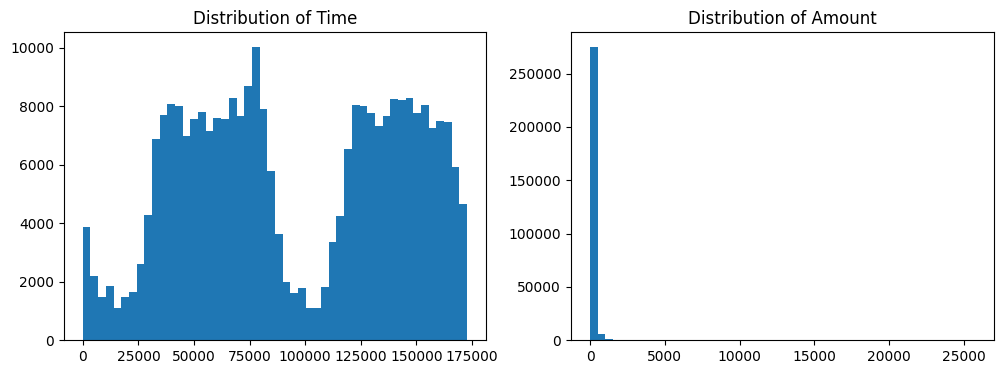

In [31]:
section("Distribution of Time and Amount")
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df["Time"], bins=50)
axes[0].set_title("Distribution of Time")
axes[1].hist(df["Amount"], bins=50)
axes[1].set_title("Distribution of Amount")
plt.show()

## Observations from feature inspection

From the inspection above, several important observations can be made.

First, the `Time` feature represents the elapsed time between transactions rather than a traditional timestamp. Its distribution appears relatively continuous across the dataset, and it does not show extreme skewness.

Second, the `Amount` feature shows a strong right-skewed distribution. This means that most transactions involve relatively small amounts, while a small number of transactions involve very large amounts.

This skewness suggests that scaling may be beneficial for certain models, especially those that are sensitive to feature magnitude such as logistic regression or support vector machines.

However, tree-based models and isolation-based anomaly detection methods are generally less sensitive to feature scaling.

Because this project compares multiple model families, I will later prepare two preprocessing pathways:
- a minimal preprocessing dataset for tree-based and anomaly detection models
- a scaled dataset for models that benefit from normalized features

## Feature grouping

Before performing data splitting and preprocessing, I want to clearly define the feature groups used in this dataset.

The dataset contains three main types of variables:

1. **Target variable**
   - `Class`  
   This indicates whether a transaction is legitimate (`0`) or fraudulent (`1`).

2. **Raw numerical variables**
   - `Time`
   - `Amount`  
   These variables were not PCA-transformed and may have different statistical properties compared to the anonymised components.

3. **PCA-transformed features**
   - `V1` to `V28`  
   These features were generated using principal component analysis to anonymise the original transaction variables. Because they are already transformed into numerical space, they usually require minimal preprocessing.

By grouping features in this way, I can make later preprocessing steps clearer and easier to reuse across different modelling pipelines.

In [32]:
section("Define feature groups")
target_column = "Class"
raw_features = ["Time", "Amount"]
pca_features = [f"V{i}" for i in range(1, 29)]
all_features = raw_features + pca_features

print("Target column:", target_column)
print("Number of raw features:", len(raw_features))
print("Number of PCA features:", len(pca_features))
print("Total features:", len(all_features))


Define feature groups
Target column: Class
Number of raw features: 2
Number of PCA features: 28
Total features: 30


In [33]:
section("Preview feature list")
print(all_features)


Preview feature list
['Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


## Why defining feature groups is useful

Explicitly defining feature groups helps make the preprocessing workflow more organised and easier to reuse.

Instead of repeatedly referencing column names throughout the notebook, I can use these feature groups when performing tasks such as:
- creating training and test datasets,
- applying scaling transformations,
- preparing inputs for different modelling approaches.

This approach also reduces the risk of accidentally omitting or duplicating features during preprocessing.

## Train–test splitting strategy

Before applying any preprocessing steps that learn from the data (such as scaling or sampling), it is important to split the dataset into training and test sets.

I perform this split at this stage to prevent **data leakage**, which occurs when information from the test data influences the training process. If preprocessing steps such as scaling or sampling are applied before splitting, the model may indirectly gain information about the test data, leading to overly optimistic evaluation results.

For this project, I use a **stratified train–test split**.

Stratification ensures that the proportion of fraudulent and legitimate transactions remains consistent in both the training and test sets. This is particularly important because the dataset is extremely imbalanced, with fraud cases representing only a small fraction of the total observations.

I use an **80–20 split**, where:
- 80% of the data is used for model training
- 20% is reserved for evaluation

This ratio provides a good balance between having enough data for training while still maintaining a sufficiently large test set for reliable evaluation.

In [34]:
section("Prepare features and target")
X = df[all_features].copy()
y = df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Prepare features and target
Feature matrix shape: (283726, 30)
Target vector shape: (283726,)


In [35]:
section("Stratified train/test split")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Stratified train/test split
Training set shape: (226980, 30)
Test set shape: (56746, 30)


In [36]:
section("Verify class distribution after split")

def class_summary(y_series, name):
    
    counts = y_series.value_counts().sort_index()
    percentages = y_series.value_counts(normalize=True).sort_index() * 100
    
    summary = pd.DataFrame({
        "count": counts,
        "percentage": percentages
    })
    
    summary.index = ["Legitimate (0)", "Fraud (1)"]
    
    print(f"\n{name}")
    print(summary)

class_summary(y_train, "Training set")

class_summary(y_test, "Test set")


Verify class distribution after split

Training set
                 count  percentage
Legitimate (0)  226602   99.833466
Fraud (1)          378    0.166534

Test set
                count  percentage
Legitimate (0)  56651   99.832587
Fraud (1)          95    0.167413


## Verification of the split

After performing the stratified train–test split, I verified the class distribution in both subsets.

The proportion of fraudulent transactions remains consistent between the training and test sets. This confirms that stratification successfully preserved the class imbalance structure of the dataset.

Maintaining this distribution is important because it ensures that the evaluation results reflect the real imbalance present in the dataset, rather than an artificial distribution created during splitting.

## Cross-validation setup

In addition to the train–test split, I also want to define a cross-validation strategy that can be reused later during model development.

I am setting this up at the preprocessing stage so that the whole workflow remains consistent across different models and team members.

For this project, I use **Stratified 5-Fold Cross-Validation**.

I chose this approach for the following reasons:
- the dataset is extremely imbalanced, so stratification is necessary to preserve the proportion of fraud and legitimate transactions in each fold,
- using multiple folds gives a more reliable estimate of model performance than relying on a single split alone,
- and 5 folds provide a practical balance between evaluation stability and computational cost.

I am not running cross-validation at this stage yet. I am only defining the configuration so that later modelling notebooks can reuse the same evaluation structure consistently.

In [37]:
section("Cross-validation configuration")

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(cv_strategy)


Cross-validation configuration
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## Why this cross-validation design is appropriate

I selected `StratifiedKFold` instead of standard K-fold cross-validation because the fraud class is extremely rare in this dataset.

Without stratification, some folds could contain too few fraudulent transactions, which would make evaluation unstable and less meaningful.

I also enabled shuffling before splitting into folds. This helps reduce the risk that any original ordering in the dataset influences how samples are distributed across folds.

Finally, I kept the same random seed used earlier in the notebook so that the cross-validation setup remains reproducible and consistent with the train–test split.

## Model-aware preprocessing design

At this stage, I need to decide how the training and test data should be prepared for later modelling.

I do not want to apply one single preprocessing approach to all models, because different model families respond differently to feature scaling.

In this project, the models are not all of the same type:
- tree-based models such as Random Forest, XGBoost, and LightGBM are generally less sensitive to feature scaling,
- Isolation Forest is also usually less dependent on standard feature scaling,
- whereas models such as Logistic Regression and One-Class SVM are more sensitive to feature magnitude and can benefit from scaled inputs.

Because of this, I will prepare **two separate preprocessing pathways**:

1. **Minimal / unscaled dataset**
   - intended for tree-based and isolation-based models

2. **Scaled dataset**
   - intended for scale-sensitive models such as Logistic Regression and One-Class SVM

This approach is more appropriate than forcing the same preprocessing onto every model, and it makes the workflow more flexible and methodologically consistent.

In [38]:
section("Create minimal preprocessing pathway")

X_train_minimal = X_train.copy()
X_test_minimal = X_test.copy()

print("Minimal training set shape:", X_train_minimal.shape)
print("Minimal test set shape:", X_test_minimal.shape)


Create minimal preprocessing pathway
Minimal training set shape: (226980, 30)
Minimal test set shape: (56746, 30)


## Why I am keeping a minimal pathway

I am keeping an unscaled version of the split data because not all models require scaling.

For example, tree-based models usually make decisions based on feature splits rather than distance or magnitude in the same way as linear or kernel-based methods. Similarly, Isolation Forest is generally more tolerant of unscaled numerical inputs than models such as Logistic Regression or One-Class SVM.

Keeping this minimal pathway is useful for two reasons:
- it avoids unnecessary transformation for models that do not strongly depend on scaling,
- and it preserves a cleaner baseline version of the dataset for comparison.

This also supports fairer experimentation across different model families.

## Choosing a scaling strategy

For the scaled pathway, I need to choose an appropriate scaling method.

I am not choosing a scaler arbitrarily. This decision is based on the observations made earlier during feature inspection:
- `Amount` showed strong right skewness,
- the dataset contains rare and potentially extreme observations,
- and some later models are sensitive to differences in feature magnitude.

Because of this, I will use **RobustScaler** as the main scaling method.

I selected `RobustScaler` instead of using standard scaling by default because it is less influenced by extreme values. It scales features using the median and interquartile range rather than the mean and standard deviation, which makes it a better starting point when the data may contain skewness or outlier-like behaviour.

I am treating this as a justified default rather than a final truth. A later modelling experiment could still compare it with `StandardScaler`, but for the preprocessing notebook, `RobustScaler` is the more defensible first choice.

In [39]:
section("Fit RobustScaler on training data only")

robust_scaler = RobustScaler()
robust_scaler.fit(X_train[all_features])

print("RobustScaler fitted successfully on the training set only.")


Fit RobustScaler on training data only
RobustScaler fitted successfully on the training set only.


In [40]:
section("Create scaled preprocessing pathway")

X_train_scaled = pd.DataFrame(
    robust_scaler.transform(X_train[all_features]),
    columns=all_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    robust_scaler.transform(X_test[all_features]),
    columns=all_features,
    index=X_test.index
)

print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled test set shape:", X_test_scaled.shape)


Create scaled preprocessing pathway
Scaled training set shape: (226980, 30)
Scaled test set shape: (56746, 30)


In [41]:
X_train_scaled.head()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
226238,0.701730,0.137472,0.995207,-1.275153,-1.216778,-1.606746,0.801946,3.294124,-1.624678,1.568787,-0.977940,1.678225,-0.136071,-0.825901,0.287471,-0.394356,0.191736,-0.652284,0.507588,-0.179578,-0.352960,-0.758170,-0.291170,-0.053017,0.933343,0.809661,-0.351619,-0.189652,0.224922,-0.467258
134253,-0.048166,-0.209119,-0.597600,1.117315,0.218671,-0.010285,-0.269912,-0.591514,0.152452,1.335234,-0.981107,-0.392871,0.977856,1.590179,0.967398,0.885747,-0.256362,0.328592,-0.226715,-0.342338,0.423512,-0.015741,-0.506390,-0.891313,1.079738,0.596931,-1.090113,-0.379079,-0.119150,0.301412
186465,0.496931,-0.098808,0.847242,-0.030402,-1.183621,0.095123,0.930577,0.755626,-0.056210,0.295944,0.271802,-0.408155,1.041684,0.882159,0.373073,-0.803605,0.743749,-0.349282,0.975066,-0.155504,-1.092294,-0.429777,0.776639,1.016689,-0.107803,-2.177118,0.134448,0.104937,0.269659,-0.491127
149493,0.076666,-0.066242,0.803526,0.180212,0.072305,2.453198,0.077371,1.111431,-0.689878,0.395842,0.592835,1.252833,0.911395,-1.872875,1.673088,1.296047,-1.695909,1.288174,-0.464917,0.825789,-1.855984,-0.480654,0.403806,0.647327,0.597222,0.832635,-0.341895,0.073567,-0.118813,-0.376486
18461,-0.649581,0.026608,0.600755,-0.844746,0.194263,-0.959130,-0.875789,0.472816,-1.105189,0.356968,-1.648326,1.602426,1.178081,-0.121057,0.261711,-0.101766,0.344636,-0.735194,0.968479,-0.640133,-0.651998,-0.867918,-0.752328,-0.601434,0.850633,-0.484676,-0.120272,-0.684600,0.376867,0.012462


## Observation after scaling

The scaled datasets have now been created successfully using the same feature set as the minimal pathway.

At this point, I have two parallel versions of the data:
- an unscaled version for models that do not strongly depend on feature scaling,
- and a robust-scaled version for models that are more sensitive to feature magnitude.

This design keeps the preprocessing workflow flexible and makes it easier for different teammates to use the version that best matches their assigned modelling approach.

## Exporting reusable preprocessing outputs

At this stage, I want to save the processed datasets so that they can be reused directly in later modelling notebooks.

I am exporting both preprocessing pathways:
- the minimal / unscaled version
- the robust-scaled version

I am also exporting the target labels separately for the training and test sets.

This makes the workflow easier for my teammates to use, because they do not need to repeat the preprocessing steps every time they want to test a model. It also helps maintain consistency across experiments, since everyone can work from the same processed inputs.

In [42]:
def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

In [47]:
section("Export processed datasets")

save_csv(X_train_minimal, OUTPUT_DIR / "X_train_minimal.csv")
save_csv(X_test_minimal, OUTPUT_DIR / "X_test_minimal.csv")

save_csv(X_train_scaled, OUTPUT_DIR / "X_train_robust_scaled.csv")
save_csv(X_test_scaled, OUTPUT_DIR / "X_test_robust_scaled.csv")

save_csv(y_train.to_frame(name="Class"), OUTPUT_DIR / "y_train.csv")
save_csv(y_test.to_frame(name="Class"), OUTPUT_DIR / "y_test.csv")


Export processed datasets
Saved: ../outputs/preprocessed/X_train_minimal.csv
Saved: ../outputs/preprocessed/X_test_minimal.csv
Saved: ../outputs/preprocessed/X_train_robust_scaled.csv
Saved: ../outputs/preprocessed/X_test_robust_scaled.csv
Saved: ../outputs/preprocessed/y_train.csv
Saved: ../outputs/preprocessed/y_test.csv


## Why exporting separate datasets is useful

I chose to export each dataset separately rather than saving everything in a single file because the preprocessing workflow is designed to support multiple modelling approaches.

This structure makes the outputs easier to reuse:
- teammates working on tree-based or isolation-based models can use the minimal datasets,
- teammates working on scale-sensitive models can use the robust-scaled datasets,
- and the target labels remain clearly separated for training and evaluation.

This also improves traceability, because each exported file has a clear purpose.

## Saving preprocessing metadata

In addition to exporting the processed datasets, I also want to save a metadata file that records the key preprocessing decisions and dataset details.

This is useful for reproducibility because it captures:
- the random seed used,
- the final dataset size,
- the split ratio,
- the scaling method,
- the number of duplicates removed,
- and the main feature groups used in the workflow.

Although this step is not strictly necessary to run models, it makes the preprocessing pipeline much more transparent and easier to document in a group project.

In [48]:
section("Save preprocessing metadata")

metadata = {
    "seed": SEED,
    "original_rows_before_duplicate_removal": rows_before,
    "final_rows_after_duplicate_removal": rows_after,
    "duplicates_removed": rows_before - rows_after,
    "test_size": 0.20,
    "cross_validation_folds": 5,
    "cross_validation_strategy": "StratifiedKFold",
    "scaling_method": "RobustScaler",
    "target_column": target_column,
    "raw_features": raw_features,
    "pca_features": pca_features,
    "all_features": all_features,
    "notes": [
        "Exact duplicate rows were removed before splitting.",
        "Train/test split was stratified to preserve class distribution.",
        "RobustScaler was fitted on training data only to avoid leakage.",
        "Two preprocessing pathways were created: minimal and robust-scaled.",
        "Sampling was intentionally not applied at preprocessing stage."
    ]
}

with open(OUTPUT_DIR / "preprocessing_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved:", OUTPUT_DIR / "preprocessing_metadata.json")


Save preprocessing metadata
Saved: ../outputs/preprocessed/preprocessing_metadata.json


## Final preprocessing summary

At the end of this notebook, I have created a reproducible preprocessing workflow for the credit card fraud dataset.

The final workflow includes:
- validation of the raw dataset structure,
- missing value and duplicate analysis,
- removal of exact duplicate rows,
- class imbalance analysis,
- inspection of the raw numerical features,
- leakage-safe stratified train–test splitting,
- cross-validation setup for later modelling,
- a minimal preprocessing pathway,
- a robust-scaled preprocessing pathway,
- and exportable outputs for downstream experiments.

This means the dataset is now ready to be used consistently across baseline, boosting, and anomaly-detection models.

## Notes for later modelling

For later modelling notebooks, I will use the exported datasets as follows:

- `X_train_minimal.csv` and `X_test_minimal.csv`
  - suitable for Random Forest, XGBoost, LightGBM, and Isolation Forest

- `X_train_robust_scaled.csv` and `X_test_robust_scaled.csv`
  - suitable for Logistic Regression and One-Class SVM

- `y_train.csv` and `y_test.csv`
  - used as the target labels for both pathways

I will not apply any sampling to the test set.

If sampling methods such as SMOTE or undersampling are used later, they should only be applied inside the training workflow, and ideally inside each training fold during cross-validation.

## Report-ready conclusion for preprocessing

Overall, the preprocessing stage showed that the dataset was structurally clean and fully numerical, with no missing values but a small number of exact duplicate rows that were removed to avoid repeated identical observations in the training data.

The most important challenge identified during preprocessing was the extreme class imbalance, which has direct implications for evaluation and model design. Feature inspection also showed that the original `Amount` variable was strongly right-skewed, which supported the use of a robust scaling pathway for scale-sensitive models.

By preparing both minimal and scaled datasets, I created a preprocessing workflow that is reproducible, leakage-safe, and suitable for multiple model families within the group project.

In [49]:
section("Check exported files")

for file_path in sorted(OUTPUT_DIR.iterdir()):
    print(file_path.name)


Check exported files
X_test_minimal.csv
X_test_robust_scaled.csv
X_train_minimal.csv
X_train_robust_scaled.csv
preprocessing_metadata.json
y_test.csv
y_train.csv


## Isolation Forest Modelling

In this section, I extend the notebook from preprocessing into model experimentation by implementing Isolation Forest for fraud detection.

I selected Isolation Forest because it is an anomaly detection algorithm, and this is relevant to the fraud detection problem where fraudulent transactions are extremely rare compared to legitimate ones. Instead of learning a direct supervised decision boundary, Isolation Forest attempts to identify unusual observations by isolating them through random feature splits.

This makes it a useful complementary approach to the supervised models used elsewhere in the project. It also allows me to explore how well anomaly-based detection performs on a highly imbalanced fraud dataset.

## Why Isolation Forest is appropriate here

Isolation Forest is suitable for this dataset because fraudulent transactions can be interpreted as anomalies within a much larger set of normal transactions.

I am using the minimal preprocessing pathway for this model rather than the scaled pathway. This decision is based on the nature of Isolation Forest, which is generally less sensitive to feature scaling than models such as Logistic Regression or One-Class SVM. Using the minimal dataset also keeps the modelling pipeline consistent with the preprocessing design prepared earlier in the notebook.

In [51]:
section("Load processed datasets for Isolation Forest")

X_train_if = pd.read_csv("../outputs/preprocessed/X_train_minimal.csv")
X_test_if = pd.read_csv("../outputs/preprocessed/X_test_minimal.csv")

y_train_if = pd.read_csv("../outputs/preprocessed/y_train.csv")["Class"].values
y_test_if = pd.read_csv("../outputs/preprocessed/y_test.csv")["Class"].values

print("Isolation Forest training shape:", X_train_if.shape)
print("Isolation Forest test shape:", X_test_if.shape)
print("Training fraud count:", int(y_train_if.sum()))
print("Test fraud count:", int(y_test_if.sum()))


Load processed datasets for Isolation Forest
Isolation Forest training shape: (226980, 30)
Isolation Forest test shape: (56746, 30)
Training fraud count: 378
Test fraud count: 95


## Experiment design

I do not want to rely on a single Isolation Forest configuration, because the performance of anomaly detection models can change significantly depending on parameter choices, especially the contamination setting.

To make the analysis more meaningful, I will run multiple experiments:
- a default baseline configuration,
- a configuration where contamination is aligned more closely with the observed fraud ratio,
- and a tuned configuration to explore whether performance can be improved.

This experimental design will help me compare how sensitive the model is to parameter choices and generate stronger findings for presentation and later reporting.

## Evaluation strategy

Because this dataset is extremely imbalanced, accuracy alone is not an appropriate metric for evaluating model performance.

A model that predicts all transactions as legitimate would still achieve very high accuracy while failing to detect fraud. For this reason, I focus on evaluation metrics that better reflect the model’s ability to identify fraudulent transactions.

The metrics used in this analysis are:

- Precision – how many predicted fraud cases are actually fraudulent  
- Recall – how many of the true fraud cases are detected  
- F1-score – balance between precision and recall  
- ROC-AUC – ability of the model to separate fraud and legitimate classes

These metrics provide a more meaningful evaluation of fraud detection performance.

In [52]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [53]:
def evaluate_model(name, y_true, y_pred):
    
    print("\n" + "="*60)
    print(f"Evaluation for: {name}")
    print("="*60)
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    try:
        roc = roc_auc_score(y_true, y_pred)
        print("\nROC-AUC Score:", round(roc, 4))
    except:
        print("\nROC-AUC could not be computed")

## Label conversion for Isolation Forest

Isolation Forest produces predictions using the following labels:

1 → normal observation  
-1 → anomaly  

However, the fraud detection dataset uses a different convention:

0 → legitimate transaction  
1 → fraudulent transaction  

To ensure consistent evaluation, I convert Isolation Forest outputs so that detected anomalies correspond to the fraud class label.

In [54]:
def convert_iforest_labels(pred):
    return np.where(pred == -1, 1, 0)

Experiment 1 — Default Isolation Forest
Experiment 2 — Contamination aligned with fraud rate
Experiment 3 — Tuned configuration

## Experiment 1 — Baseline Isolation Forest

In the first experiment, I use a baseline Isolation Forest configuration to establish a reference point for later comparison.

I am starting with a relatively simple setup rather than tuning parameters immediately, because I want to observe the model’s default behaviour on this dataset first. This helps me understand whether the model is already capable of identifying fraudulent transactions as anomalies and how much improvement is achieved through later parameter adjustments.

The baseline experiment therefore acts as an initial benchmark for the Isolation Forest approach.

In [55]:
from sklearn.ensemble import IsolationForest

In [56]:
section("Experiment 1 - Baseline Isolation Forest")

iso_baseline = IsolationForest(
    n_estimators=100,
    max_samples="auto",
    contamination="auto",
    random_state=SEED,
    n_jobs=-1
)

iso_baseline.fit(X_train_if)

print("Baseline Isolation Forest fitted successfully.")


Experiment 1 - Baseline Isolation Forest
Baseline Isolation Forest fitted successfully.


## Why this baseline configuration was chosen

For the baseline experiment, I kept the configuration simple and close to a default starting point.

I used:
- `n_estimators = 100` to provide a stable but computationally reasonable number of trees,
- `max_samples = "auto"` so that the algorithm uses its standard internal sampling behaviour,
- and `contamination = "auto"` to observe how the model behaves before explicitly aligning the anomaly proportion with the fraud rate.

This gives me a neutral reference point for evaluating whether later parameter choices improve fraud detection performance.

In [58]:
baseline_raw_pred = iso_baseline.predict(X_test_if)
baseline_pred = convert_iforest_labels(baseline_raw_pred)

evaluate_model("Isolation Forest - Baseline", y_test_if, baseline_pred)


Evaluation for: Isolation Forest - Baseline

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9607    0.9798     56651
           1     0.0334    0.8105    0.0641        95

    accuracy                         0.9604     56746
   macro avg     0.5165    0.8856    0.5220     56746
weighted avg     0.9981    0.9604    0.9782     56746


Confusion Matrix:
[[54422  2229]
 [   18    77]]

ROC-AUC Score: 0.8856


In [59]:
baseline_anomalies = int(baseline_pred.sum())

print("Predicted fraud/anomaly cases:", baseline_anomalies)
print("Actual fraud cases in test set:", int(y_test_if.sum()))

Predicted fraud/anomaly cases: 2306
Actual fraud cases in test set: 95


## Experiment 2 — Contamination aligned with fraud rate

In this experiment, I adjust the contamination parameter to better reflect the expected proportion of anomalies in the dataset.

Earlier analysis of the dataset showed that fraudulent transactions represent approximately 0.17% of the total observations. Since Isolation Forest requires an estimate of the anomaly proportion, I set the contamination parameter close to this observed fraud rate.

This allows the model to treat roughly the same proportion of transactions as potential anomalies, which should improve its ability to detect fraudulent behaviour compared to the baseline configuration.

In [60]:
section("Experiment 2 - Contamination aligned with fraud rate")

iso_contamination = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    max_samples="auto",
    random_state=SEED,
    n_jobs=-1
)

iso_contamination.fit(X_train_if)

print("Isolation Forest with contamination aligned to fraud rate fitted successfully.")


Experiment 2 - Contamination aligned with fraud rate
Isolation Forest with contamination aligned to fraud rate fitted successfully.


In [62]:
section("Experiment 2 - Contamination aligned with fraud rate")

iso_contamination = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    max_samples="auto",
    random_state=SEED,
    n_jobs=-1
)

iso_contamination.fit(X_train_if)

print("Isolation Forest with contamination aligned to fraud rate fitted successfully.")


Experiment 2 - Contamination aligned with fraud rate
Isolation Forest with contamination aligned to fraud rate fitted successfully.


In [63]:
cont_raw_pred = iso_contamination.predict(X_test_if)
cont_pred = convert_iforest_labels(cont_raw_pred)

evaluate_model("Isolation Forest - Contamination aligned", y_test_if, cont_pred)


Evaluation for: Isolation Forest - Contamination aligned

Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9984    0.9985     56651
           1     0.1802    0.2105    0.1942        95

    accuracy                         0.9971     56746
   macro avg     0.5894    0.6045    0.5964     56746
weighted avg     0.9973    0.9971    0.9972     56746


Confusion Matrix:
[[56560    91]
 [   75    20]]

ROC-AUC Score: 0.6045


In [64]:
cont_anomalies = int(cont_pred.sum())

print("Predicted fraud/anomaly cases:", cont_anomalies)
print("Actual fraud cases in test set:", int(y_test_if.sum()))

Predicted fraud/anomaly cases: 111
Actual fraud cases in test set: 95


## Experiment 3 — Tuned Isolation Forest

In this experiment, I adjust several key parameters of the Isolation Forest model to explore whether a better balance between fraud detection and false positive rate can be achieved.

The baseline experiment produced very high recall but also a large number of false positives, while the contamination-aligned configuration reduced false alarms but missed many fraud cases.

To explore a compromise between these two behaviours, I increase the number of trees and slightly adjust the contamination level. Increasing the number of estimators can help stabilise the anomaly detection process, while a moderate contamination value may allow the model to identify suspicious transactions without producing excessive false alarms.

In [65]:
section("Experiment 3 - Tuned Isolation Forest")

iso_tuned = IsolationForest(
    n_estimators=400,
    max_samples=256,
    contamination=0.004,
    random_state=SEED,
    n_jobs=-1
)

iso_tuned.fit(X_train_if)

print("Tuned Isolation Forest fitted successfully.")


Experiment 3 - Tuned Isolation Forest
Tuned Isolation Forest fitted successfully.


In [66]:
tuned_raw_pred = iso_tuned.predict(X_test_if)
tuned_pred = convert_iforest_labels(tuned_raw_pred)

evaluate_model("Isolation Forest - Tuned", y_test_if, tuned_pred)


Evaluation for: Isolation Forest - Tuned

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9962    0.9976     56651
           1     0.1406    0.3684    0.2035        95

    accuracy                         0.9952     56746
   macro avg     0.5698    0.6823    0.6005     56746
weighted avg     0.9975    0.9952    0.9962     56746


Confusion Matrix:
[[56437   214]
 [   60    35]]

ROC-AUC Score: 0.6823


In [67]:
tuned_anomalies = int(tuned_pred.sum())

print("Predicted fraud/anomaly cases:", tuned_anomalies)
print("Actual fraud cases in test set:", int(y_test_if.sum()))

Predicted fraud/anomaly cases: 249
Actual fraud cases in test set: 95


## Comparing Isolation Forest experiments

After running three Isolation Forest configurations, I now want to compare them in a structured way.

The goal of this section is to summarise the trade-offs between fraud detection performance and false positive behaviour across:
- the baseline configuration,
- the contamination-aligned configuration,
- and the tuned configuration.

This comparison is important because anomaly detection performance should not be judged using a single metric alone. In fraud detection, it is necessary to understand how many fraud cases were detected, how many were missed, and how many legitimate transactions were incorrectly flagged as suspicious.

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [69]:
def get_experiment_summary(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    summary = {
        "Experiment": name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Fraud Detected": tp,
        "Fraud Missed": fn,
        "Predicted Anomalies": int(np.sum(y_pred)),
        "Actual Fraud Cases": int(np.sum(y_true)),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }
    
    return summary

In [70]:
baseline_summary = get_experiment_summary(
    "Baseline",
    y_test_if,
    baseline_pred
)

cont_summary = get_experiment_summary(
    "Fraud-rate aligned",
    y_test_if,
    cont_pred
)

tuned_summary = get_experiment_summary(
    "Tuned",
    y_test_if,
    tuned_pred
)

comparison_df = pd.DataFrame([
    baseline_summary,
    cont_summary,
    tuned_summary
])

comparison_df

,Experiment,True Negatives,False Positives,False Negatives,True Positives,Fraud Detected,Fraud Missed,Predicted Anomalies,Actual Fraud Cases,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,54422,2229,18,77,77,18,2306,95,0.033391,0.810526,0.064140,0.885590
1,Fraud-rate aligned,56560,91,75,20,20,75,111,95,0.180180,0.210526,0.194175,0.604460
2,Tuned,56437,214,60,35,35,60,249,95,0.140562,0.368421,0.203488,0.682322


## Comparison table

The table below summarises the performance of the three Isolation Forest experiments.

This comparison helps me evaluate how the model behaviour changes when the contamination parameter and other settings are adjusted. In particular, I want to compare:
- how many fraud cases were detected,
- how many legitimate transactions were incorrectly flagged,
- and whether the balance between recall and false positives improves across experiments.

In [71]:
comparison_display = comparison_df[[
    "Experiment",
    "Fraud Detected",
    "Fraud Missed",
    "False Positives",
    "Predicted Anomalies",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].copy()

comparison_display

,Experiment,Fraud Detected,Fraud Missed,False Positives,Predicted Anomalies,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,77,18,2229,2306,0.033391,0.810526,0.064140,0.885590
1,Fraud-rate aligned,20,75,91,111,0.180180,0.210526,0.194175,0.604460
2,Tuned,35,60,214,249,0.140562,0.368421,0.203488,0.682322


In [72]:
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIGURES_DIR.resolve())

Figures will be saved to: /Users/harsh/DM_CW/outputs/figures


## Visual comparison of fraud detection and false positives

I now visualise the experiments to make the trade-offs easier to interpret.

For fraud detection problems, two particularly important questions are:
- how many fraud cases the model was able to detect,
- and how many legitimate transactions were incorrectly flagged as suspicious.

These charts make that trade-off much clearer than a table alone and are suitable for direct use in the presentation slides.

## ROC curve comparison across Isolation Forest experiments

To compare the three Isolation Forest configurations more visually, I now plot the ROC curves on the same figure.

Although ROC-AUC should not be interpreted alone in a highly imbalanced fraud dataset, the ROC curve is still useful for comparing how the three configurations separate fraudulent and legitimate transactions. Plotting the curves together makes it easier to observe which experiment achieves stronger overall discrimination.

In [81]:
from sklearn.metrics import roc_curve, auc

In [82]:
# Isolation Forest decision_function gives anomaly scores where
# higher values indicate more normal points.
# To make the score align with fraud detection, we multiply by -1
# so that higher values indicate more anomalous transactions.

baseline_scores = -iso_baseline.decision_function(X_test_if)
cont_scores = -iso_contamination.decision_function(X_test_if)
tuned_scores = -iso_tuned.decision_function(X_test_if)

In [83]:
fpr_baseline, tpr_baseline, _ = roc_curve(y_test_if, baseline_scores)
fpr_cont, tpr_cont, _ = roc_curve(y_test_if, cont_scores)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test_if, tuned_scores)

auc_baseline = auc(fpr_baseline, tpr_baseline)
auc_cont = auc(fpr_cont, tpr_cont)
auc_tuned = auc(fpr_tuned, tpr_tuned)

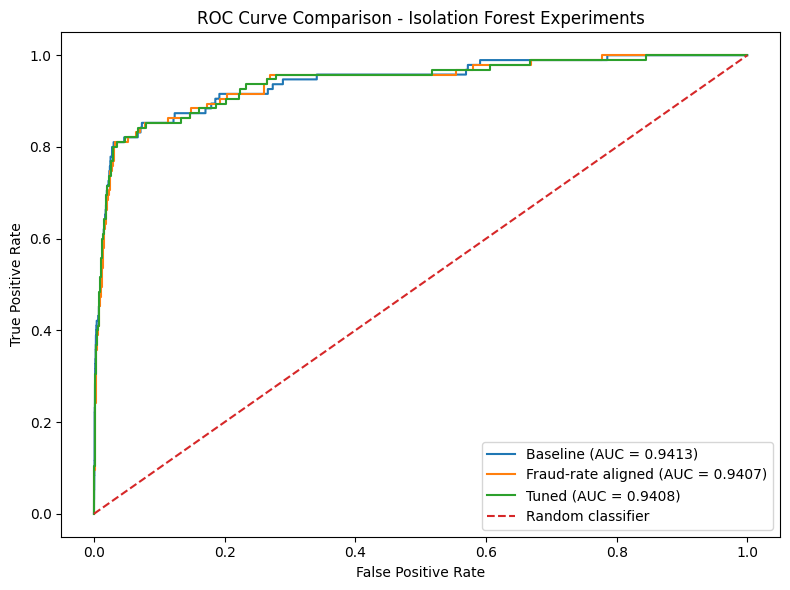

In [84]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_baseline, tpr_baseline, label=f"Baseline (AUC = {auc_baseline:.4f})")
plt.plot(fpr_cont, tpr_cont, label=f"Fraud-rate aligned (AUC = {auc_cont:.4f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned (AUC = {auc_tuned:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Isolation Forest Experiments")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation of ROC curve comparison

The ROC curve comparison provides a visual summary of how the three Isolation Forest configurations perform across different decision thresholds.

This figure is useful for presentation because it shows the overall ranking of the experiments more clearly than a single metric alone. However, because the dataset is extremely imbalanced, the ROC curve should still be interpreted alongside precision, recall, false positives, and other fraud-specific evaluation measures.

## Precision-Recall curve comparison across Isolation Forest experiments

Because this dataset is highly imbalanced, the Precision-Recall curve is especially important. It focuses more directly on the model’s ability to detect fraudulent transactions without being overly influenced by the large number of legitimate cases.

For this reason, I compare the Precision-Recall curves of the three experiments alongside the ROC analysis.

In [85]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [86]:
precision_baseline, recall_baseline, _ = precision_recall_curve(y_test_if, baseline_scores)
precision_cont, recall_cont, _ = precision_recall_curve(y_test_if, cont_scores)
precision_tuned, recall_tuned, _ = precision_recall_curve(y_test_if, tuned_scores)

ap_baseline = average_precision_score(y_test_if, baseline_scores)
ap_cont = average_precision_score(y_test_if, cont_scores)
ap_tuned = average_precision_score(y_test_if, tuned_scores)

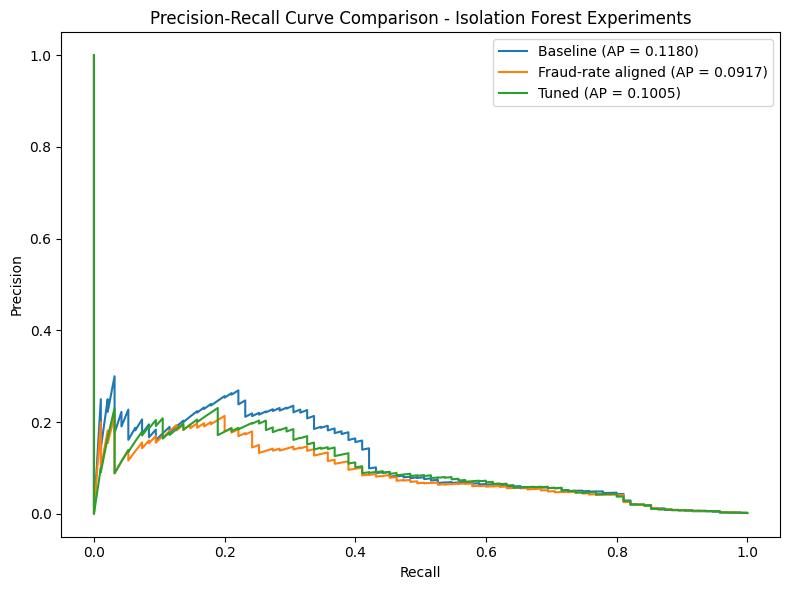

In [87]:
plt.figure(figsize=(8, 6))

plt.plot(recall_baseline, precision_baseline, label=f"Baseline (AP = {ap_baseline:.4f})")
plt.plot(recall_cont, precision_cont, label=f"Fraud-rate aligned (AP = {ap_cont:.4f})")
plt.plot(recall_tuned, precision_tuned, label=f"Tuned (AP = {ap_tuned:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison - Isolation Forest Experiments")
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_pr_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation of Precision-Recall comparison

The Precision-Recall curve is particularly informative for fraud detection because it focuses on the trade-off between detecting fraudulent transactions and limiting false alarms.

This comparison provides a more realistic view of model usefulness in an imbalanced setting, and it is especially suitable for presentation when discussing why accuracy alone is not a reliable measure of performance.

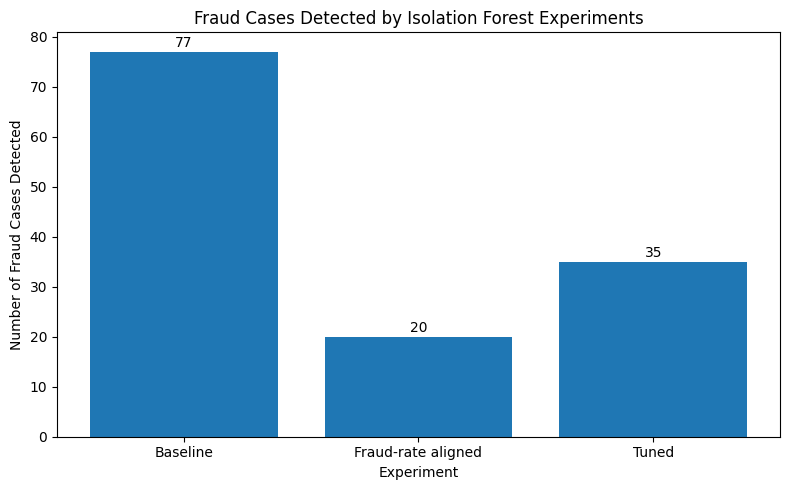

In [73]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Experiment"], comparison_df["Fraud Detected"])
plt.title("Fraud Cases Detected by Isolation Forest Experiments")
plt.ylabel("Number of Fraud Cases Detected")
plt.xlabel("Experiment")

for i, value in enumerate(comparison_df["Fraud Detected"]):
    plt.text(i, value + 1, str(value), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_fraud_detected.png", dpi=300, bbox_inches="tight")
plt.show()

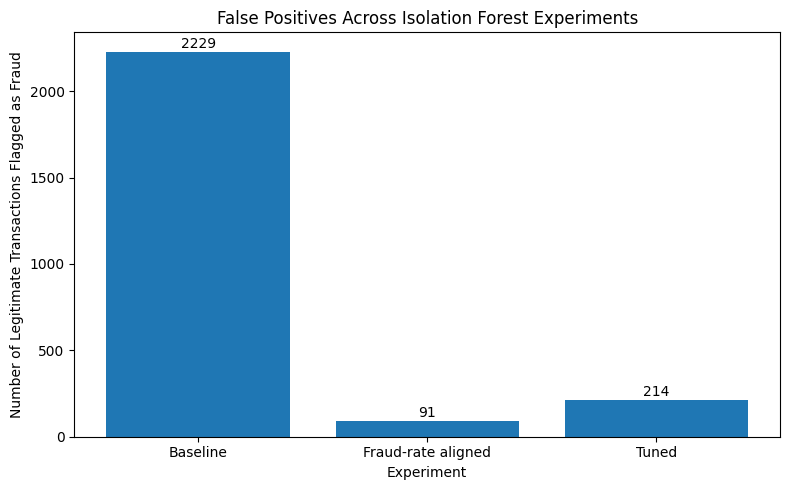

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Experiment"], comparison_df["False Positives"])
plt.title("False Positives Across Isolation Forest Experiments")
plt.ylabel("Number of Legitimate Transactions Flagged as Fraud")
plt.xlabel("Experiment")

for i, value in enumerate(comparison_df["False Positives"]):
    plt.text(i, value + max(comparison_df["False Positives"]) * 0.01, str(value), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_false_positives.png", dpi=300, bbox_inches="tight")
plt.show()

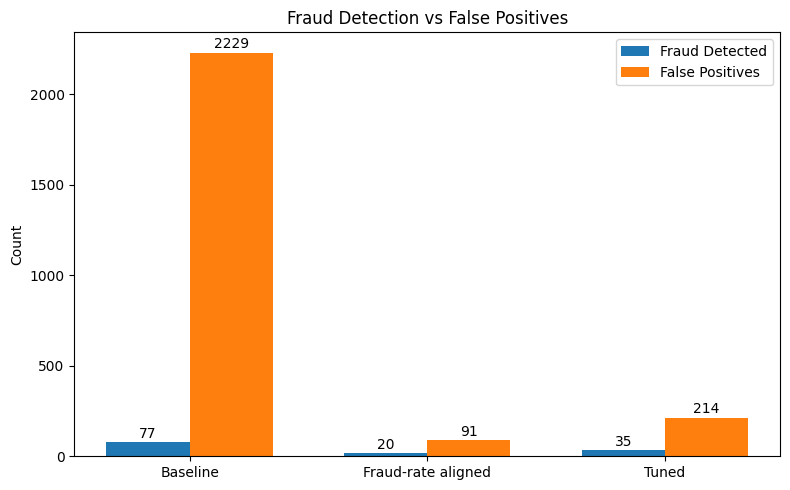

In [75]:
plt.figure(figsize=(8, 5))

x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df["Fraud Detected"], width, label="Fraud Detected")
plt.bar(x + width/2, comparison_df["False Positives"], width, label="False Positives")

plt.xticks(x, comparison_df["Experiment"])
plt.ylabel("Count")
plt.title("Fraud Detection vs False Positives")
plt.legend()

for i, value in enumerate(comparison_df["Fraud Detected"]):
    plt.text(i - width/2, value + max(comparison_df["False Positives"]) * 0.01, str(value), ha="center")

for i, value in enumerate(comparison_df["False Positives"]):
    plt.text(i + width/2, value + max(comparison_df["False Positives"]) * 0.01, str(value), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_detection_vs_falsepositives.png", dpi=300, bbox_inches="tight")
plt.show()

## Metric comparison

In addition to raw detection counts, I also compare evaluation metrics across experiments.

This is important because the most suitable Isolation Forest configuration cannot be decided from recall or ROC-AUC alone. A model may detect many fraud cases but also produce too many false positives, while another model may reduce false alarms but miss too much fraud.

The following visualisations compare precision, recall, F1-score, and ROC-AUC across the three experiments.

In [76]:
metric_cols = ["Precision", "Recall", "F1 Score", "ROC-AUC"]

metric_df = comparison_df[["Experiment"] + metric_cols].copy()
metric_df

,Experiment,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.033391,0.810526,0.064140,0.885590
1,Fraud-rate aligned,0.180180,0.210526,0.194175,0.604460
2,Tuned,0.140562,0.368421,0.203488,0.682322


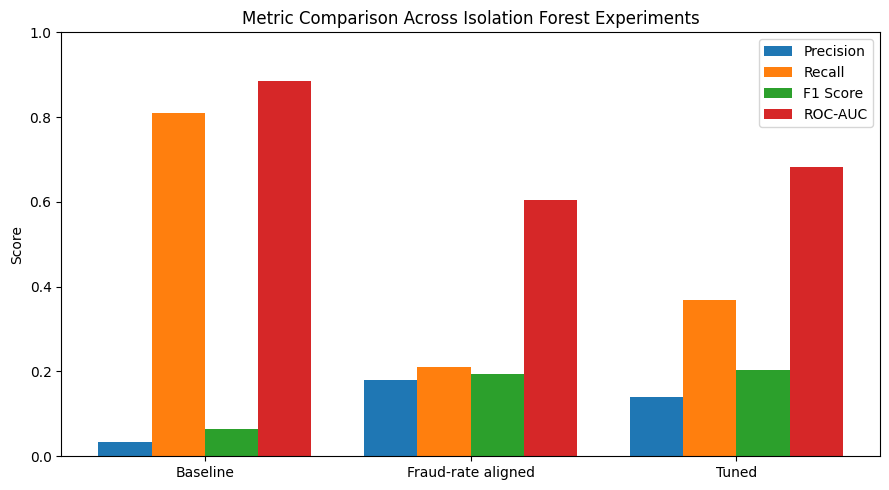

In [77]:
plt.figure(figsize=(9, 5))

x = np.arange(len(metric_df))
width = 0.2

for idx, metric in enumerate(metric_cols):
    plt.bar(x + (idx - 1.5) * width, metric_df[metric], width, label=metric)

plt.xticks(x, metric_df["Experiment"])
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Metric Comparison Across Isolation Forest Experiments")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

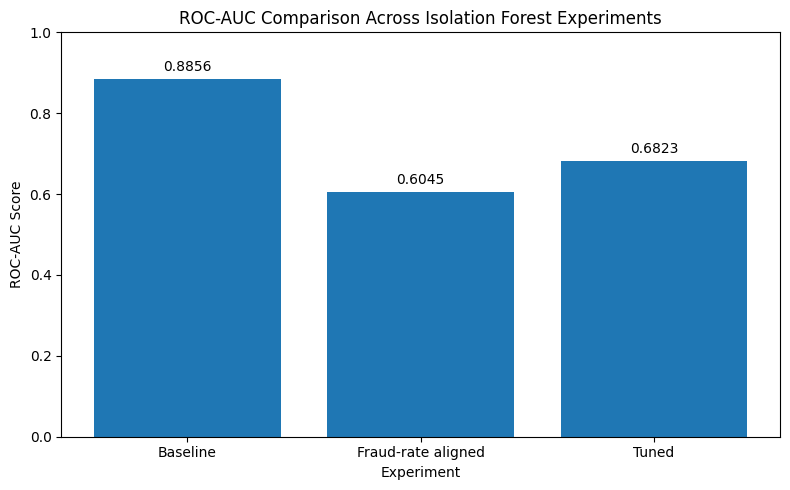

In [78]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Experiment"], comparison_df["ROC-AUC"])
plt.title("ROC-AUC Comparison Across Isolation Forest Experiments")
plt.ylabel("ROC-AUC Score")
plt.xlabel("Experiment")
plt.ylim(0, 1.0)

for i, value in enumerate(comparison_df["ROC-AUC"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_roc_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Optional slide-ready summary chart

For presentation purposes, a single summary chart can sometimes communicate the key trade-off more clearly than multiple separate figures.

The chart below compares the two most presentation-relevant quantities:
- fraud cases detected,
- false positives generated.

This is especially useful for explaining the trade-off between aggressive anomaly detection and false alarm control.

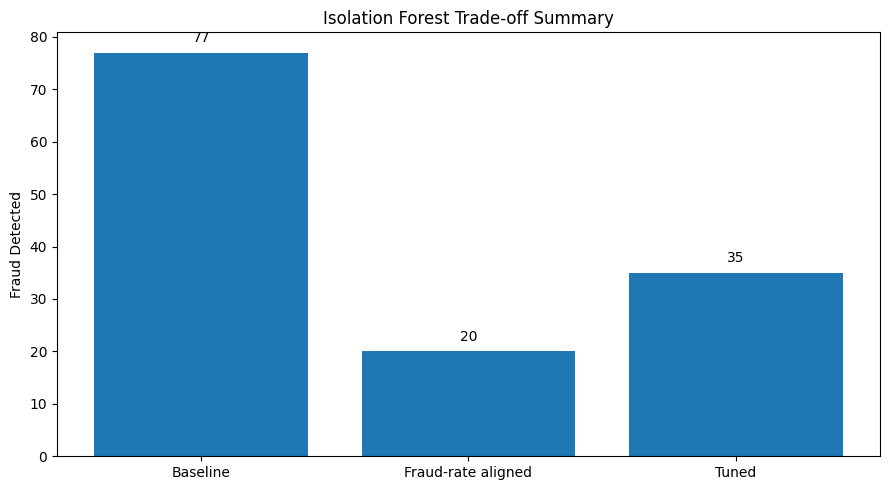

In [79]:
fig, ax1 = plt.subplots(figsize=(9, 5))

x = np.arange(len(comparison_df))

ax1.bar(x, comparison_df["Fraud Detected"])
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df["Experiment"])
ax1.set_ylabel("Fraud Detected")
ax1.set_title("Isolation Forest Trade-off Summary")

for i, value in enumerate(comparison_df["Fraud Detected"]):
    ax1.text(i, value + 2, str(value), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "iforest_tradeoff_summary_simple.png", dpi=300, bbox_inches="tight")
plt.show()

In [80]:
comparison_display_rounded = comparison_display.copy()

for col in ["Precision", "Recall", "F1 Score", "ROC-AUC"]:
    comparison_display_rounded[col] = comparison_display_rounded[col].round(4)

comparison_display_rounded.to_csv(FIGURES_DIR / "iforest_experiment_summary_table.csv", index=False)

comparison_display_rounded

,Experiment,Fraud Detected,Fraud Missed,False Positives,Predicted Anomalies,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,77,18,2229,2306,0.033400,0.810500,0.064100,0.885600
1,Fraud-rate aligned,20,75,91,111,0.180200,0.210500,0.194200,0.604500
2,Tuned,35,60,214,249,0.140600,0.368400,0.203500,0.682300


## Interpretation of visual comparison

The visual comparison shows that the baseline Isolation Forest configuration achieved the strongest fraud detection performance, but this came at the cost of a very large number of false positives. In contrast, the contamination-aligned configuration greatly reduced false alarms but missed a large proportion of fraudulent transactions. The tuned model provided an intermediate behaviour, detecting more fraud cases than the contamination-aligned experiment while producing substantially fewer false positives than the baseline.

These results indicate that Isolation Forest does not produce a single universally best configuration in this problem setting. Instead, the parameter choice determines the trade-off between aggressive fraud detection and control of false alarms. This is an important practical challenge in applying anomaly detection methods to highly imbalanced fraud datasets.